**🌐 Language:** **English** | [한국어 →](/regression/06-grouped-and-dummy-regression-minimal-ko)

# 06 - Grouped and Dummy Regression (Minimal)

Grouped regression can recover the same idea from aggregated data when we keep group means and group counts. Dummy regression turns discrete categories into 0/1 indicators, so coefficients become differences in means or conditional differences in means.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

plt.style.use("fivethirtyeight")


## Load Data

We use only `wage.csv`.


In [2]:
wage = (pd.read_csv("data/wage.csv")
        .dropna(subset=["wage", "hours", "educ", "IQ", "lhwage"])
        .assign(hwage=lambda d: d["wage"] / d["hours"],
                T=lambda d: (d["educ"] > 12).astype(int))
        .copy())

wage[["wage", "hours", "hwage", "lhwage", "educ", "IQ", "T"]].head()


,wage,hours,hwage,lhwage,educ,IQ,T
0,769,40,19.225,2.956212,12,93,0
1,808,50,16.160,2.782539,18,119,1
2,825,40,20.625,3.026504,14,108,1
3,650,40,16.250,2.788093,12,96,0
4,562,40,14.050,2.642622,11,74,0


## Grouped Regression

Aggregate wages by years of education, then compare weighted and unweighted grouped regressions to the individual-data regression.


In [3]:
group_wage = (wage
              .groupby("educ", as_index=False)
              .agg(lhwage=("lhwage", "mean"),
                   count=("lhwage", "size")))

individual_model = smf.ols("lhwage ~ educ", data=wage).fit()
grouped_weighted_model = smf.wls("lhwage ~ educ", data=group_wage, weights=group_wage["count"]).fit()
grouped_unweighted_model = smf.ols("lhwage ~ educ", data=group_wage).fit()

pd.DataFrame(
    {
        "coef_on_educ": [
            individual_model.params["educ"],
            grouped_weighted_model.params["educ"],
            grouped_unweighted_model.params["educ"],
        ],
        "std_error": [
            individual_model.bse["educ"],
            grouped_weighted_model.bse["educ"],
            grouped_unweighted_model.bse["educ"],
        ],
    },
    index=["Individual OLS", "Grouped WLS", "Grouped OLS"],
).round(4)


,coef_on_educ,std_error
Individual OLS,0.0529,0.0065
Grouped WLS,0.0529,0.0057
Grouped OLS,0.0481,0.0059


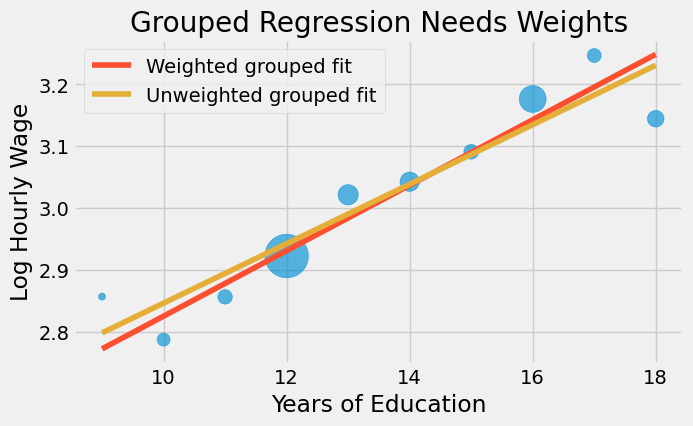

In [4]:
ax = group_wage.plot.scatter(x="educ", y="lhwage", s=group_wage["count"] * 2.5, alpha=0.65, figsize=(7, 4))
educ_grid = pd.DataFrame({"educ": sorted(wage["educ"].unique())})
ax.plot(educ_grid["educ"], grouped_weighted_model.predict(educ_grid), color="C1", label="Weighted grouped fit")
ax.plot(educ_grid["educ"], grouped_unweighted_model.predict(educ_grid), color="C2", label="Unweighted grouped fit")
ax.set_title("Grouped Regression Needs Weights")
ax.set_xlabel("Years of Education")
ax.set_ylabel("Log Hourly Wage")
ax.legend()
plt.show()


## Dummy Regression

Use a treatment dummy for completing more than 12 years of education, then compare that dummy model with a fully categorical regression on years of education.


In [5]:
dummy_model = smf.ols("hwage ~ T", data=wage).fit()
conditional_dummy_model = smf.ols("hwage ~ T + IQ", data=wage).fit()
categorical_model = smf.ols("hwage ~ C(educ)", data=wage).fit()

pd.DataFrame(
    {
        "coef_on_T": [dummy_model.params["T"], conditional_dummy_model.params["T"]],
        "intercept": [dummy_model.params["Intercept"], conditional_dummy_model.params["Intercept"]],
        "coef_on_IQ": [float("nan"), conditional_dummy_model.params["IQ"]],
    },
    index=["Dummy only", "Dummy + IQ"],
).round(4)


,coef_on_T,intercept,coef_on_IQ
Dummy only,4.9044,19.9405,NaN
Dummy + IQ,3.1573,8.0956,0.1253


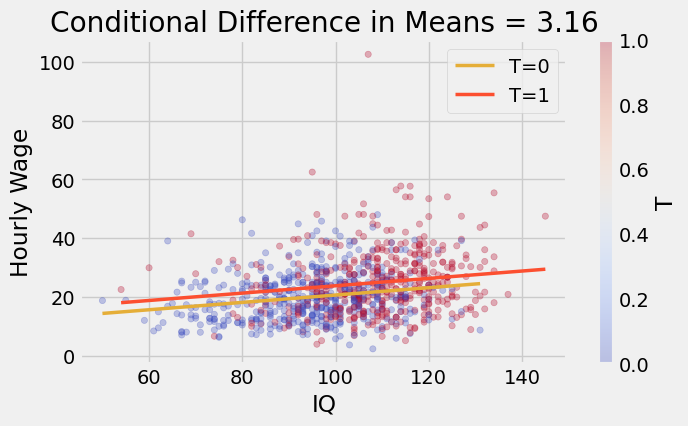

,educ,mean_hourly_wage
0,9,18.560000
1,10,17.772594
2,11,18.668373
3,12,20.307866
4,13,22.888960


In [6]:
ax = wage.plot.scatter(x="IQ", y="hwage", c="T", cmap="coolwarm", alpha=0.3, figsize=(7, 4))
plot_df = wage.sort_values(["T", "IQ"]).copy()
plot_df["y_hat"] = conditional_dummy_model.predict(plot_df)
for t_value, color, label in [(0, "C2", "T=0"), (1, "C1", "T=1")]:
    subset = plot_df.query("T == @t_value")
    ax.plot(subset["IQ"], subset["y_hat"], color=color, linewidth=2.5, label=label)
ax.set_title(f"Conditional Difference in Means = {conditional_dummy_model.params["T"]:.2f}")
ax.set_xlabel("IQ")
ax.set_ylabel("Hourly Wage")
ax.legend()
plt.show()

wage.groupby("educ", as_index=False)["hwage"].mean().rename(columns={"hwage": "mean_hourly_wage"}).head()


## Result

With grouped data, weighted regression stays close to the individual-data result because large groups get more influence. With dummy regression, coefficients become differences in means, and a categorical specification removes the need to force education into a single linear slope.
